#### SETUP

In [ ]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.image import grayscale_to_rgb
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_from_pretrained
from breast_cancer.utils import get_save_path
from breast_cancer.train import train_model
from breast_cancer.utils.plots import plot_history

2025-09-21 11:21:43.819396: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 11:21:43.887927: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-21 11:21:43.903830: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-21 11:21:44.208733: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvi

In [2]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_pretrained.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [4]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(exist_ok=True)

In [5]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

In [6]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [7]:
EPOCHS = 80

## MODEL STARTING POINT

In [8]:
from tensorflow.keras.applications import EfficientNetV2S

# Build backbone from pretrained model
new_cfg = model_cfg["base_model_args"].copy()
backbone = EfficientNetV2S(**model_cfg["base_model_args"])

# Build model from spec
model = build_from_pretrained(backbone, model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}_{backbone.name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

2025-09-21 11:21:45.090443: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 11:21:45.196152: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22177 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


Model: "pretrained"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 efficientnetv2-s (Functiona  (None, 8, 8, 1280)       20331360  
 l)                                                              
                                                                 
 transition_layer (GlobalAve  (None, 1280)             0         
 ragePooling2D)                                                  
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                        

## MODEL EXPLORATION

#### Split by image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-7


In [ ]:
ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [ ]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("efficientnetv2-s")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [12]:
# Train head only
history_image1 = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


2025-09-21 11:21:55.683996: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-21 11:21:55.705130: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 11:21:55.714397: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 11:21:55.714434: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 11:21:55.720049: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 11:21:55.720178: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 11:21:55.806702: I tensorflow/stream_executor/cuda/c

323/323 [==============================] - 23s 54ms/step - loss: 6.7100 - auc: 0.4974 - binary_accuracy: 0.4990 - precision: 0.4060 - recall: 0.4636 - val_loss: 6.1689 - val_auc: 0.4874 - val_binary_accuracy: 0.4119 - val_precision: 0.4119 - val_recall: 1.0000 - lr: 1.0000e-04
Epoch 2/80
323/323 [==============================] - 17s 51ms/step - loss: 5.8653 - auc: 0.4946 - binary_accuracy: 0.5040 - precision: 0.4072 - recall: 0.4444 - val_loss: 5.3786 - val_auc: 0.5066 - val_binary_accuracy: 0.4171 - val_precision: 0.4137 - val_recall: 0.9958 - lr: 1.0000e-04
Epoch 3/80
323/323 [==============================] - 17s 51ms/step - loss: 5.1340 - auc: 0.4968 - binary_accuracy: 0.5086 - precision: 0.4062 - recall: 0.4145 - val_loss: 4.7057 - val_auc: 0.5066 - val_binary_accuracy: 0.4223 - val_precision: 0.4147 - val_recall: 0.9788 - lr: 1.0000e-04
Epoch 4/80
323/323 [==============================] - 17s 51ms/step - loss: 4.4977 - auc: 0.4883 - binary_accuracy: 0.5103 - precision: 0.4036 -

In [13]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_image2 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


323/323 [==============================] - 17s 51ms/step - loss: 0.6817 - auc: 0.4930 - binary_accuracy: 0.5853 - precision: 0.4122 - recall: 0.0127 - val_loss: 0.6811 - val_auc: 0.4906 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-05
Epoch 2/80
323/323 [==============================] - 17s 51ms/step - loss: 0.6813 - auc: 0.4961 - binary_accuracy: 0.5859 - precision: 0.4233 - recall: 0.0107 - val_loss: 0.6804 - val_auc: 0.4938 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-05
Epoch 3/80
323/323 [==============================] - 18s 53ms/step - loss: 0.6816 - auc: 0.4980 - binary_accuracy: 0.5852 - precision: 0.3588 - recall: 0.0072 - val_loss: 0.6802 - val_auc: 0.4905 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-05
Epoch 4/80
323/323 [==============================] - 19s 52ms/step - loss: 0.6812 - auc: 0.4939 - binary_accuracy: 0.58

In [14]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_image3 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


323/323 [==============================] - 17s 51ms/step - loss: 0.6793 - auc: 0.5051 - binary_accuracy: 0.5876 - precision: 1.0000 - recall: 2.3516e-04 - val_loss: 0.6791 - val_auc: 0.4848 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 2.6214e-06
Epoch 2/80
323/323 [==============================] - 17s 51ms/step - loss: 0.6794 - auc: 0.5014 - binary_accuracy: 0.5875 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.6794 - val_auc: 0.4821 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 2.6214e-06
Epoch 3/80
323/323 [==============================] - 17s 52ms/step - loss: 0.6791 - auc: 0.5132 - binary_accuracy: 0.5875 - precision: 0.5000 - recall: 1.1758e-04 - val_loss: 0.6798 - val_auc: 0.4813 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 2.6214e-06
Epoch 4/80
323/323 [==============================] - ETA: 0s - loss: 0.6792 - auc: 0.5064 - binary_accu

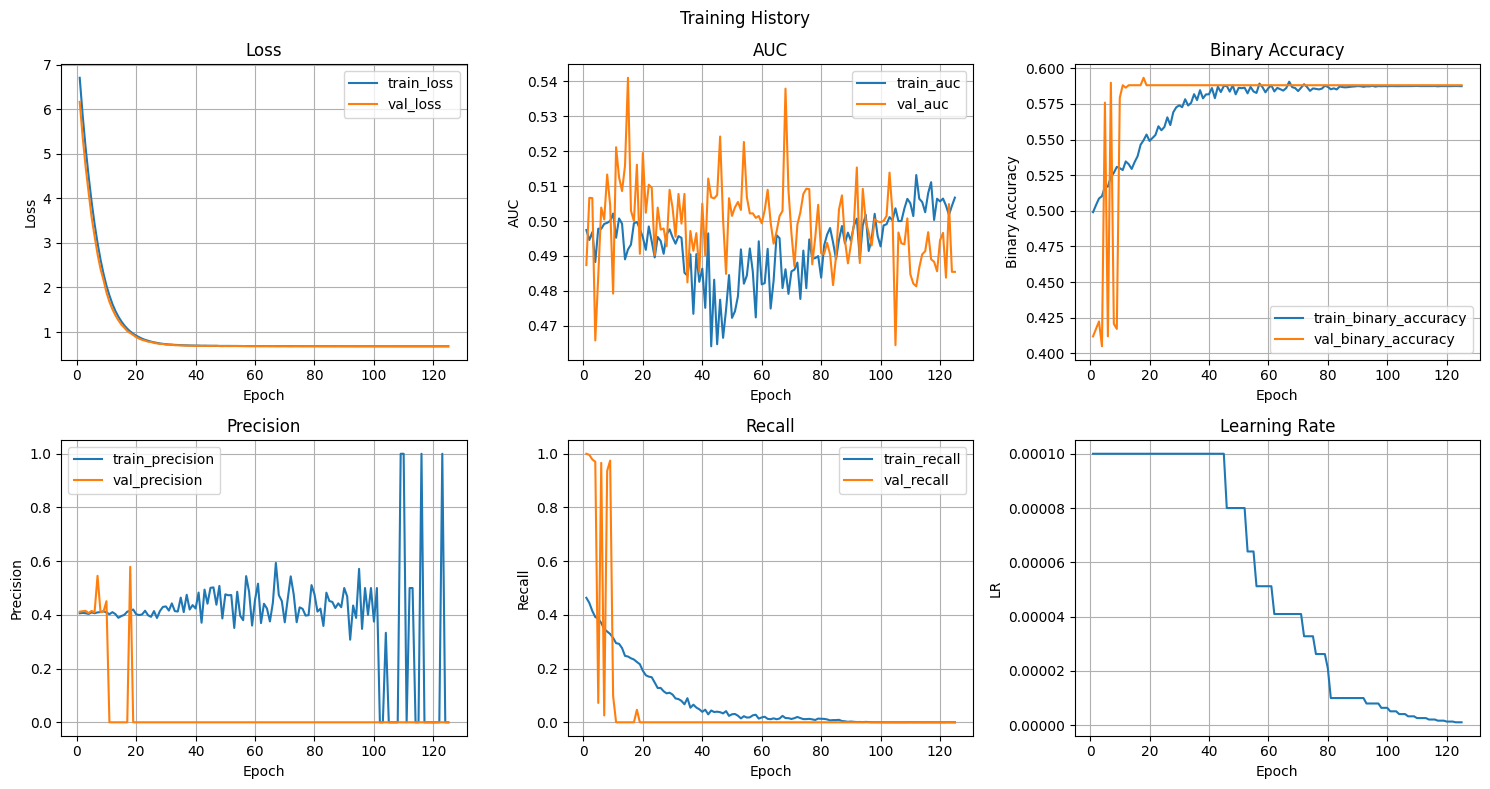

In [15]:
def append_histories(*histories):
    import re
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            new_k = re.sub(r'_\d+$', '', k)
            merged.setdefault(new_k, []).extend(v)
    return merged

all_histories = append_histories(history_image1, history_image2, history_image3)

plot_history(all_histories)

In [16]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/initial_pretrained_efficientnetv2-s_image_random.csv'

#### Split by Patient ID

In [17]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [18]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [19]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("efficientnetv2-s")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [20]:
# Train head only
history_patient1 = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
232/316 [=====================>........] - ETA: 4s - loss: 6.8307 - auc_1: 0.4841 - binary_accuracy: 0.5038 - precision_1: 0.2486 - recall_1: 0.4474

316/316 [==============================] - 22s 55ms/step - loss: 6.7228 - auc_1: 0.4928 - binary_accuracy: 0.4987 - precision_1: 0.3966 - recall_1: 0.4605 - val_loss: 6.1482 - val_auc_1: 0.4998 - val_binary_accuracy: 0.3955 - val_precision_1: 0.3955 - val_recall_1: 1.0000 - lr: 1.0000e-04
Epoch 2/80
316/316 [==============================] - 17s 51ms/step - loss: 5.8871 - auc_1: 0.4868 - binary_accuracy: 0.4992 - precision_1: 0.3908 - recall_1: 0.4273 - val_loss: 5.4166 - val_auc_1: 0.4686 - val_binary_accuracy: 0.3918 - val_precision_1: 0.3904 - val_recall_1: 0.9575 - lr: 1.0000e-04
Epoch 3/80
316/316 [==============================] - 17s 52ms/step - loss: 5.1424 - auc_1: 0.4969 - binary_accuracy: 0.5120 - precision_1: 0.4002 - recall_1: 0.4154 - val_loss: 4.7165 - val_auc_1: 0.4934 - val_binary_accuracy: 0.4011 - val_precision_1: 0.3938 - val_recall_1: 0.9528 - lr: 1.0000e-04
Epoch 4/80
316/316 [==============================] - 19s 54ms/step - loss: 4.4839 - auc_1: 0.4996 - binary_

In [21]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_patient2 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


316/316 [==============================] - 17s 51ms/step - loss: 0.6783 - auc_1: 0.5042 - binary_accuracy: 0.5933 - precision_1: 0.3529 - recall_1: 0.0073 - val_loss: 0.6738 - val_auc_1: 0.5136 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 1.0000e-05
Epoch 2/80
316/316 [==============================] - 17s 51ms/step - loss: 0.6789 - auc_1: 0.4937 - binary_accuracy: 0.5935 - precision_1: 0.3750 - recall_1: 0.0081 - val_loss: 0.6741 - val_auc_1: 0.5088 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 1.0000e-05
Epoch 3/80
316/316 [==============================] - 17s 51ms/step - loss: 0.6786 - auc_1: 0.4938 - binary_accuracy: 0.5946 - precision_1: 0.4294 - recall_1: 0.0086 - val_loss: 0.6741 - val_auc_1: 0.5044 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 1.0000e-05
Epoch 4/80
315/316 [============================>.] - ETA: 0s - loss: 0.6783 - auc_1

In [22]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_patient3 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


316/316 [==============================] - 17s 51ms/step - loss: 0.6767 - auc_1: 0.5076 - binary_accuracy: 0.5957 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_loss: 0.6735 - val_auc_1: 0.4969 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 2.0972e-06
Epoch 2/80
316/316 [==============================] - 17s 51ms/step - loss: 0.6771 - auc_1: 0.4960 - binary_accuracy: 0.5957 - precision_1: 0.5000 - recall_1: 1.2237e-04 - val_loss: 0.6735 - val_auc_1: 0.4900 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 2.0972e-06
Epoch 3/80
316/316 [==============================] - 17s 51ms/step - loss: 0.6767 - auc_1: 0.5006 - binary_accuracy: 0.5958 - precision_1: 1.0000 - recall_1: 1.2237e-04 - val_loss: 0.6741 - val_auc_1: 0.4963 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 2.0972e-06
Epoch 4/80
315/316 [============================>.] - ETA: 0s - loss

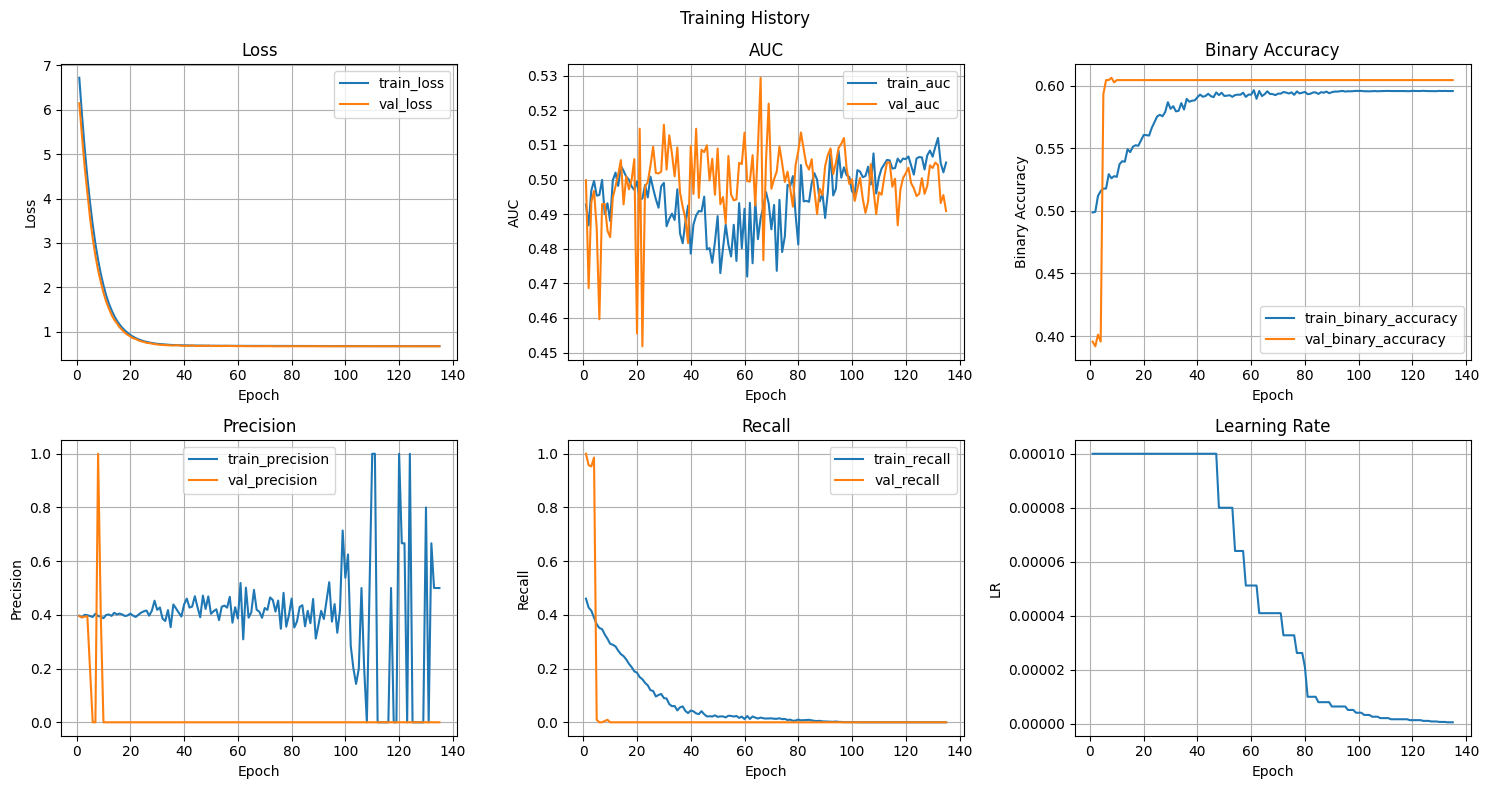

In [23]:
all_histories = append_histories(history_patient1, history_patient2, history_patient3)

plot_history(all_histories)

In [24]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/initial_pretrained_efficientnetv2-s_patient_random.csv'